In [2]:
%pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.9 MB 2.4 MB/s eta 0:00:04
   --- ------------------------------------ 0.8/8.9 MB 2.8 MB/s eta 0:00:03
   ------- -------------------------------- 1.6/8.9 MB 2.5 MB/s eta 0:00:03
   --------- ------------------------------ 2.1/8.9 MB 2.6 MB/s eta 0:00:03
   ----------- ---------------------------- 2.6/8.9 MB 2.6 MB/s eta 0:00:03
   -------------- ------------------------- 3.1/8.9 MB 2.5 MB/s eta 0:00:03
   ----------------- ---------------------- 3.9/8.9 MB 2.6 MB/s eta 0:00:02
   -------------------- ------------------- 4.5/8.9 MB 2.7 MB/s eta 0:00:02
   ---------------------- ----------------- 5.0/8.9 MB 2.6 MB/s eta 0:00:02
   ------------------------ --------------- 5.5/8.9 MB 2.6 MB/s eta 0:00:02
   --------------------------- --------

In [3]:
# Cell 1: Initialization and Diagnostic Engine Loading
import sys
from pathlib import Path
import os

# Add project root to python path
root_path = Path.cwd().parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

from src.config import CHECKPOINT_DIR, TRAIN_PATH
from src.dataset import get_data_loaders
from src.evaluate import evaluate_saved_model, plot_confusion_matrix

# 1. Get data loaders (we only need test_ds here)
_, _, test_ds = get_data_loaders()

# 2. Extract class names alphabetically from folder layout
class_names = sorted([f for f in os.listdir(TRAIN_PATH) if not f.startswith('.')])
model_file_path = CHECKPOINT_DIR / "best_baseline_model.keras"

print(f"Targeting classes: {class_names}")

Initializing Data Pipelines...
Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
Targeting classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


Loading best saved model from: c:\Users\indra\OneDrive\Pictures\DeepTrain\DeepTrain\outputs\checkpoints\best_baseline_model.keras
Running inference on test dataset...

================ CLASSIFICATION REPORT ================
              precision    recall  f1-score   support

   buildings       0.73      0.87      0.79       437
      forest       0.92      0.96      0.94       474
     glacier       0.74      0.85      0.79       553
    mountain       0.73      0.79      0.76       525
         sea       0.92      0.62      0.74       510
      street       0.87      0.77      0.82       501

    accuracy                           0.81      3000
   macro avg       0.82      0.81      0.81      3000
weighted avg       0.82      0.81      0.80      3000



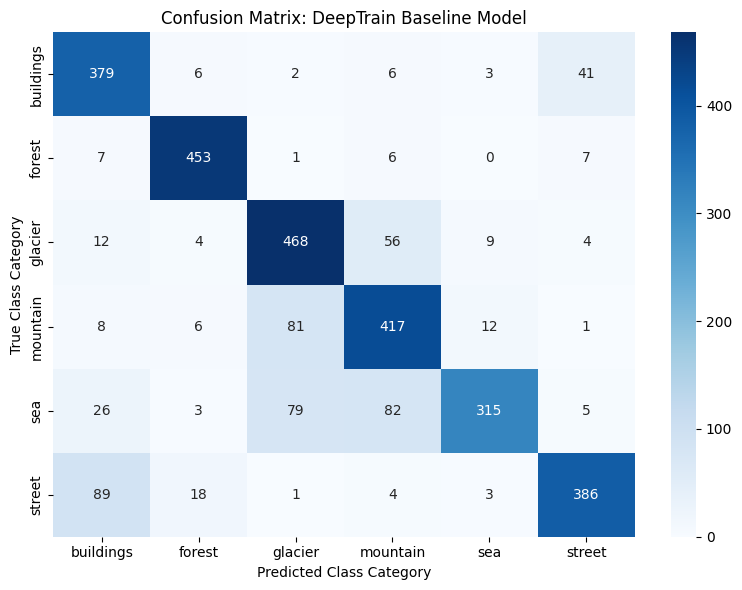

In [4]:
# Cell 2: Execute Diagnostics
report, cm, y_true, y_pred = evaluate_saved_model(model_file_path, test_ds, class_names)

print("\n================ CLASSIFICATION REPORT ================")
print(report)
print("=======================================================")

# Render the matrix heatmap
plot_confusion_matrix(cm, class_names)